In [1]:
import os

target_dir = "../data/raw/financial-fraud-detection-dataset"
csv_file = os.path.join(target_dir, "Synthetic_Financial_datasets_log.csv")

In [2]:
import pandas as pd

df = pd.read_csv(csv_file)
df.shape

(6362620, 11)

In [3]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

Drop unusable columns due to Kaggle rule

In [4]:
df.drop(['oldbalanceOrg', 'newbalanceOrig','newbalanceDest','oldbalanceDest'], axis=1, inplace=True)
df.shape

(6362620, 7)

Confirming that merchants as nameDest do not exhibit fraud

In [5]:
merchants_only = df[df['nameDest'].str.contains("M")]

print(f'Unique values for \'isFraud\' column: {merchants_only['isFraud'].unique()}')
print(f'Unique values for \'isFlaggedFraud\' column: {merchants_only['isFlaggedFraud'].unique()}')

Unique values for 'isFraud' column: [0]
Unique values for 'isFlaggedFraud' column: [0]


No merchants as source accounts

In [6]:
merchantsOrig = df[df['nameOrig'].str.contains("M")]

merchantsOrig.shape

(0, 7)

Remove transactions where nameDest are Merchants

In [7]:
filtered_df = df[~df['nameDest'].str.contains("M")]

print(filtered_df.shape)
df = filtered_df    #set back dataset to 'df' variable name for ease of usage

(4211125, 7)


Place dataset in directory for other models to use

In [8]:
# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw(without Merchants)", exist_ok=True)

target_dir = "../data/raw(without Merchants)"
full_file_path = os.path.join(target_dir, 'Dataset without Merchants.csv')

df.to_csv(full_file_path, index=False)

In [9]:
# sample = df.sample(frac=0.1, random_state=42)

Identify accounts appearing both as nameOrig and nameDest

In [10]:
senders = set(df['nameOrig'].unique())
receivers = set(df['nameDest'].unique())


overlap_accounts = senders.intersection(receivers)

print(f"Total unique senders: {len(senders)}")
print(f"Total unique receivers: {len(receivers)}")
print(f"Accounts appearing as both sender and receiver: {len(overlap_accounts)}")
print(f'\n')


suspicious_df = df[df['nameOrig'].isin(overlap_accounts) | df['nameDest'].isin(overlap_accounts)]

Total unique senders: 4207035
Total unique receivers: 571961
Accounts appearing as both sender and receiver: 1152




Rate of transactions involve overlapping accounts

In [11]:
total_txn = df.shape[0]
overlap_txn = suspicious_df.shape[0]
print(f"Percentage of transactions involving dual-role accounts: {(overlap_txn / total_txn) * 100:.2f}%")

# Fraud rate among overlapping accounts
fraud_overlap = suspicious_df['isFraud'].sum()
fraud_rate_overlap = fraud_overlap / suspicious_df.shape[0]
overall_fraud_rate = df['isFraud'].mean()

print(f"Fraud rate (overlap accounts): {fraud_rate_overlap:.4f}")
print(f"Overall fraud rate (entire dataset): {overall_fraud_rate:.4f}")

Percentage of transactions involving dual-role accounts: 0.23%
Fraud rate (overlap accounts): 0.0013
Overall fraud rate (entire dataset): 0.0020


In [12]:
suspicious_df['type'].value_counts()

type
CASH_OUT    5219
CASH_IN     3225
TRANSFER    1218
DEBIT         91
Name: count, dtype: int64

In [21]:
# Get the index (nameDest) of top irregular receivers
i = suspicious_df

# Print each irregular receiver
for customer in i['nameOrig']:    
    # Get transactions for this receiver
    # receiver_txns = df[df['nameOrig'] == customer | df['nameDest'] == customer]
    as_sender = df[df['nameOrig'] == customer]
    as_receiver = df[df['nameDest'] == customer]


    all_txns = pd.concat([as_sender,as_receiver])
    if all_txns['isFraud'].sum() == 0:
        continue
    
    print(f"Receiver ID: {customer}")
    print(f"Number of transactions: {len(all_txns)}")
    print(f"Fraud transactions: {all_txns['isFraud'].sum()}")
    print(f"Fraud rate: {(all_txns['isFraud'].sum() / len(all_txns)) * 100:.2f}%")
    print("-" * 50)

KeyboardInterrupt: 

Number of transactions sent and received by each Account

In [15]:
# Count number of transactions each user has sent
num_sent = df.groupby('nameOrig').size().reset_index(name='numSent')

# Count number of transactions each user has received
num_received = df.groupby('nameDest').size().reset_index(name='numReceived')

# Merge 'numSent' into main df
df = df.merge(num_sent, on='nameOrig', how='left')

# Merge 'numReceived' into main df
df = df.merge(num_received, on='nameDest', how='left')

# Fill NaN (e.g., users who never received anything) with 0
df[['numSent', 'numReceived']] = df[['numSent', 'numReceived']].fillna(0)


In-Degree and Out-Degree for each Account

In [ ]:
num_unique_dest = (
    df.groupby('nameOrig')['nameDest']
      .nunique()
      .reset_index(name='numUniqueDest')
)

num_unique_orig = (
    df.groupby('nameDest')['nameOrig']
      .nunique()
      .reset_index(name='numUniqueOrig')
)

# Merge sender-based feature
df = df.merge(num_unique_dest, on='nameOrig', how='left')

# Merge receiver-based feature
df = df.merge(num_unique_orig, on='nameDest', how='left')

# Fill missing values (e.g., accounts that never sent or never received)
df[['numUniqueDest', 'numUniqueOrig']] = df[['numUniqueDest', 'numUniqueOrig']].fillna(0)

Transanction Recency: Steps since last transaction by nameOrig

In [ ]:
df = df.sort_values(by=['nameOrig', 'step']).reset_index(drop=True)

df['transactionRecency'] = df.groupby('nameOrig')['step'].diff()

df['transactionRecency'] = df['transactionRecency'].fillna(df['step'])

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

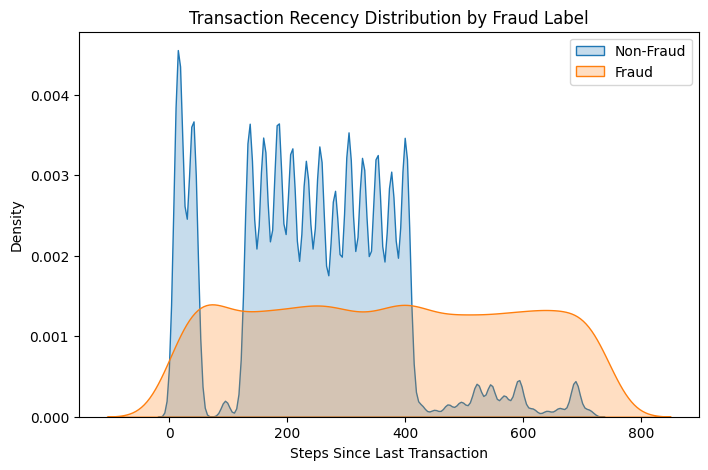

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(df[df['isFraud']==0]['transactionRecency'], label='Non-Fraud', fill=True)
sns.kdeplot(df[df['isFraud']==1]['transactionRecency'], label='Fraud', fill=True)
plt.title('Transaction Recency Distribution by Fraud Label')
plt.xlabel('Steps Since Last Transaction')
plt.legend()
plt.show()

### Transaction Type Sequence
Encoding of last N transaction types by `nameOrig` (e.g., "CASH-IN → TRANSFER → CASH-OUT")     
- Fraud follows predictable patterns: cash-in to load funds, transfer to move them, cash-out to extract.

In [ ]:
def create_transaction_sequence_features_efficient(df, n_last_transactions):
    # Sort by customer and time
    df = df.sort_values(['nameOrig', 'step']).reset_index(drop=True)
    
    # Create lagged transaction types
    for i in range(1, n_last_transactions + 1):
        df[f'prev_type_{i}'] = df.groupby('nameOrig')['type'].shift(i)
    
    # Create sequence string
    sequence_cols = [f'prev_type_{i}' for i in range(n_last_transactions, 0, -1)] + ['type']
    df['transaction_sequence'] = df[sequence_cols].apply(
        lambda x: '→'.join([str(t) if pd.notna(t) else 'START' for t in x]), 
        axis=1
    )
    
    # Frequency encoding for sequences
    sequence_freq = df['transaction_sequence'].value_counts(normalize=True).to_dict()
    df['sequence_frequency'] = df['transaction_sequence'].map(sequence_freq)
    
    # Flag specific fraud patterns (binary features - memory efficient)
    
    df['is_transfer_cashout'] = (
        (df['prev_type_1'] == 'TRANSFER') & 
        (df['type'] == 'CASH_OUT')
    ).astype(int)
    
    df['is_cashout_transfer'] = (
        (df['prev_type_1'] == 'CASH_OUT') & 
        (df['type'] == 'TRANSFER')
    ).astype(int)  # 9x higher fraud rate!
    
    df['is_transfer_transfer'] = (
        (df['prev_type_1'] == 'TRANSFER') & 
        (df['type'] == 'TRANSFER')
    ).astype(int)  # 8x higher fraud rate!
    
    df['is_first_transfer'] = (
        (df['prev_type_1'] == 'START') & 
        (df['type'] == 'TRANSFER')
    ).astype(int)  # 4x higher fraud rate
    
    df['is_cashin_cashout'] = (
        (df['prev_type_1'] == 'CASH_IN') & 
        (df['type'] == 'CASH_OUT')
    ).astype(int)  # 4x higher fraud rate
    

    df['is_early_transaction'] = (
        (df['prev_type_2'] == 'START') | 
        (df['prev_type_3'] == 'START')
    ).astype(int)
    
    # Label encode previous transaction types (instead of one-hot)
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    
    for i in range(1, n_last_transactions + 1):
        col_name = f'prev_type_{i}'
        df[f'{col_name}_encoded'] = le.fit_transform(df[col_name].fillna('NONE'))
    
    # Count sequence repetitions
    df['sequence_count'] = df.groupby(['nameOrig', 'transaction_sequence']).cumcount() + 1
    
    # # Drop the string columns to save memory (keep encoded versions)
    # df = df.drop([f'prev_type_{i}' for i in range(1, n_last_transactions + 1)], axis=1)
    # df = df.drop('transaction_sequence', axis=1)
    
    return df


# Apply the efficient function
df_with_sequences = create_transaction_sequence_features_efficient(df, n_last_transactions=5)

In [ ]:
df = df_with_sequences

# Analyze fraud patterns in your data
fraud_patterns = df[df['isFraud'] == 1].groupby('transaction_sequence').size().sort_values(ascending=False)
legit_patterns = df[df['isFraud'] == 0].groupby('transaction_sequence').size().sort_values(ascending=False)

print("Top 10 Fraud Sequences:")
print(fraud_patterns.head(10))

print("\nTop 10 Legitimate Sequences:")
print(legit_patterns.head(10))

# Calculate fraud rate by sequence
sequence_fraud_rate = df.groupby('transaction_sequence').agg({
    'isFraud': ['sum', 'count', 'mean']
}).round(4)
sequence_fraud_rate.columns = ['fraud_count', 'total_count', 'fraud_rate']
sequence_fraud_rate = sequence_fraud_rate.sort_values('fraud_rate', ascending=False)

print("\nSequences with highest fraud rates:")
print(sequence_fraud_rate.head(15))

Top 10 Fraud Sequences:
transaction_sequence
START→START→START→START→START→CASH_OUT       4107
START→START→START→START→START→TRANSFER       4091
START→START→START→START→CASH_IN→CASH_OUT        5
START→START→START→START→CASH_OUT→TRANSFER       5
START→START→START→START→CASH_OUT→CASH_OUT       3
START→START→START→START→TRANSFER→CASH_OUT       1
START→START→START→START→TRANSFER→TRANSFER       1
dtype: int64

Top 10 Legitimate Sequences:
transaction_sequence
START→START→START→START→START→CASH_OUT       2231249
START→START→START→START→START→CASH_IN        1397915
START→START→START→START→START→TRANSFER        528279
START→START→START→START→START→DEBIT            41394
START→START→START→START→CASH_OUT→CASH_OUT       1137
START→START→START→START→CASH_OUT→CASH_IN         755
START→START→START→START→CASH_IN→CASH_OUT         704
START→START→START→START→CASH_IN→CASH_IN          438
START→START→START→START→CASH_OUT→TRANSFER        299
START→START→START→START→TRANSFER→CASH_OUT        261
dtype: int6

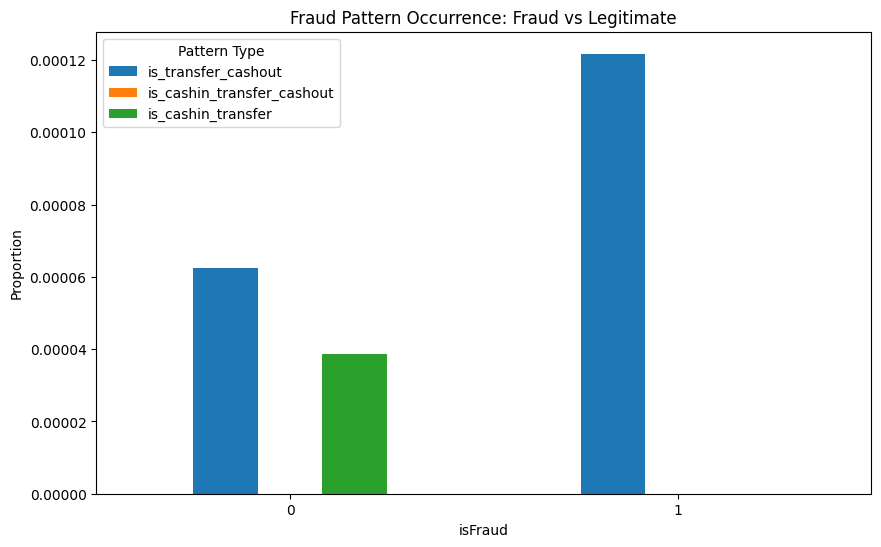

         is_transfer_cashout  is_cashin_transfer_cashout  is_cashin_transfer
isFraud                                                                     
0                   0.000062                         0.0            0.000039
1                   0.000122                         0.0            0.000000


In [ ]:
# Compare transaction patterns between fraud and legitimate users
import matplotlib.pyplot as plt
import seaborn as sns

# Fraud pattern flags comparison
pattern_comparison = df.groupby('isFraud')[
    ['is_transfer_cashout', 'is_cashin_transfer_cashout', 'is_cashin_transfer']
].mean()

pattern_comparison.plot(kind='bar', figsize=(10, 6))
plt.title('Fraud Pattern Occurrence: Fraud vs Legitimate')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Pattern Type')
plt.show()

print(pattern_comparison)

In [ ]:
# Analyze how quickly fraudulent sequences occur
fraud_sequences = df[df['is_transfer_cashout'] == 1].copy()
fraud_sequences['time_since_prev'] = fraud_sequences.groupby('nameOrig')['step'].diff()

print("Time between TRANSFER and CASH_OUT (in hours):")
print(fraud_sequences['time_since_prev'].describe())

# Compare with legitimate sequences
legit_sequences = df[(df['is_transfer_cashout'] == 0) & (df['type'] == 'CASH_OUT')].copy()
legit_sequences['time_since_prev'] = legit_sequences.groupby('nameOrig')['step'].diff()

print("\nLegitimate CASH_OUT timing:")
print(legit_sequences['time_since_prev'].describe())

Time between TRANSFER and CASH_OUT (in hours):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: time_since_prev, dtype: float64

Legitimate CASH_OUT timing:
count    1142.000000
mean      157.220665
std       125.281630
min         0.000000
25%        51.000000
50%       138.500000
75%       232.000000
max       700.000000
Name: time_since_prev, dtype: float64


In [ ]:
# What they mean:
df['is_transfer_cashout']  # 1 = Last transaction was TRANSFER, current is CASH_OUT
                           # 0 = Different pattern

df['is_cashin_transfer_cashout']  # 1 = Last 3 transactions follow fraud pattern
                                   # 0 = Different pattern


df['sequence_frequency']  # e.g., 0.0001 means 0.01% of all transactions follow this sequence

df['sequence_count']  # e.g., 3 means this customer has done this exact sequence 3 times before

0          1
1          1
2          1
3          1
4          1
          ..
4211120    1
4211121    1
4211122    1
4211123    1
4211124    1
Name: sequence_count, Length: 4211125, dtype: int64

In [ ]:
incoming = df[['step', 'nameDest', 'amount']].copy()
incoming.rename(columns={'nameDest': 'account', 'amount': 'amountReceived'}, inplace=True)

outgoing = df[['step', 'nameOrig', 'amount']].copy()
outgoing.rename(columns={'nameOrig': 'account', 'amount': 'amountSent'}, inplace=True)

# Merge incoming and outgoing on account
merged = incoming.merge(outgoing, on='account', how='inner')

In [ ]:
# Compute hours between received and sent transactions
merged['hours_diff'] = merged['step_y'] - merged['step_x']

# Keep only transactions where outgoing occurs within 24h *after* receiving
within_24h = merged[(merged['hours_diff'] > 0) & (merged['hours_diff'] <= 24)]

# Total received funds
total_received = incoming.groupby('account')['amountReceived'].sum().reset_index()

# Funds forwarded within 24h
forwarded_24h = within_24h.groupby('account')['amountSent'].sum().reset_index(name='amountForwarded24h')

# Merge totals
funds_forwarding = total_received.merge(forwarded_24h, on='account', how='left')

# Compute percentage
funds_forwarding['pctForwarded24h'] = (
    funds_forwarding['amountForwarded24h'] / funds_forwarding['amountReceived'] * 100
)

# Replace NaN (accounts that didn’t forward anything) with 0
funds_forwarding['pctForwarded24h'] = funds_forwarding['pctForwarded24h'].fillna(0)

df = df.merge(funds_forwarding[['account', 'pctForwarded24h']],
              left_on='nameOrig', right_on='account', how='left')
df.drop(columns='account', inplace=True)

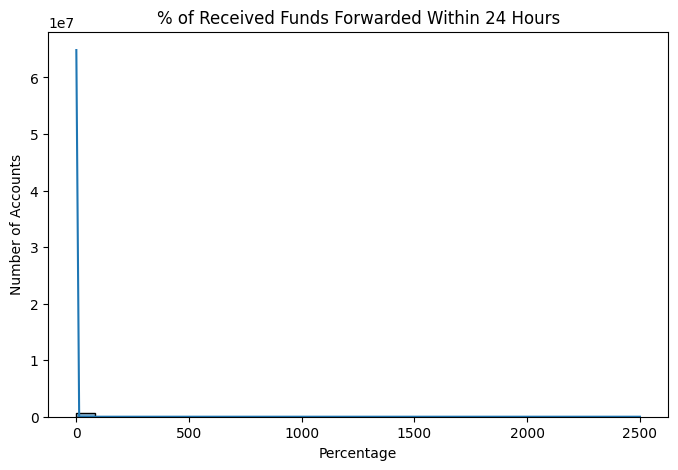

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(funds_forwarding['pctForwarded24h'], bins=30, kde=True)
plt.title('% of Received Funds Forwarded Within 24 Hours')
plt.xlabel('Percentage')
plt.ylabel('Number of Accounts')
plt.show()

In [ ]:
pair_frequency = (
    df.groupby(['nameOrig', 'nameDest'])
      .size()
      .reset_index(name='pairFrequency')
)

df = df.merge(pair_frequency, on=['nameOrig', 'nameDest'], how='left')

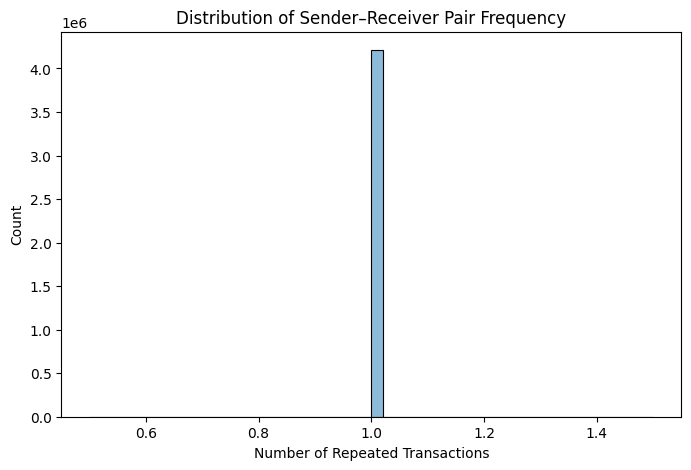

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['pairFrequency'], bins=50, kde=True)
plt.title('Distribution of Sender–Receiver Pair Frequency')
plt.xlabel('Number of Repeated Transactions')
plt.ylabel('Count')
plt.show()

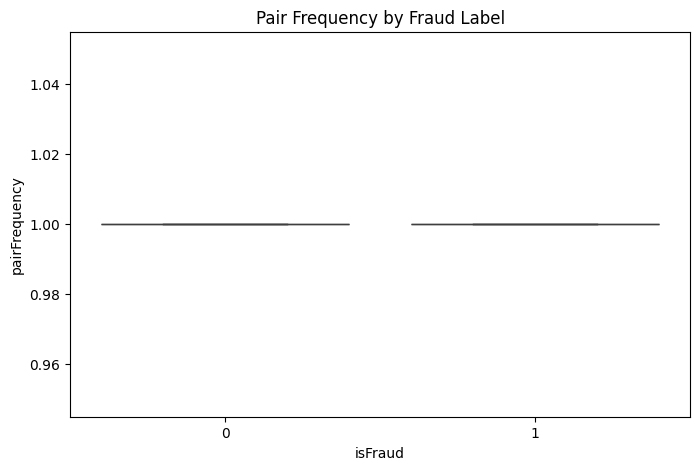

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='isFraud', y='pairFrequency')
plt.title('Pair Frequency by Fraud Label')
plt.show()


In [19]:
import numpy as np

is_bidirectional - Critical for detecting money laundering cycles where money flows A→B→A

In [16]:
# 1. Bidirectional flow - CRITICAL for detecting money laundering cycles
sender_receivers = df.groupby('nameOrig')['nameDest'].apply(set).to_dict()
receiver_senders = df.groupby('nameDest')['nameOrig'].apply(set).to_dict()

df['is_bidirectional'] = df.apply(
    lambda row: 1 if row['nameOrig'] in receiver_senders.get(row['nameDest'], set()) else 0,
    axis=1
)

print(f"Bidirectional transactions: {df['is_bidirectional'].sum()}")
print(f"Fraud rate in bidirectional: {df[df['is_bidirectional']==1]['isFraud'].mean():.4f}")
print(f"Overall fraud rate: {df['isFraud'].mean():.4f}")

Bidirectional transactions: 4211125
Fraud rate in bidirectional: 0.0020
Overall fraud rate: 0.0020


is_early_txn - Flags first 3 transactions (new accounts have higher fraud rates)

In [17]:
# 2. Transaction position - First transactions are higher risk
df = df.sort_values(['nameOrig', 'step']).reset_index(drop=True)
df['txn_position'] = df.groupby('nameOrig').cumcount() + 1
df['is_early_txn'] = (df['txn_position'] <= 3).astype(int)

print(f"Fraud rate in first 3 txns: {df[df['is_early_txn']==1]['isFraud'].mean():.4f}")

Fraud rate in first 3 txns: 0.0020


is_amount_outlier - Statistical anomaly detection (Z-score > 2 from sender's pattern)

In [20]:
# 3. Amount deviation - Anomalous amounts are suspicious
sender_amount_stats = df.groupby('nameOrig')['amount'].agg(['mean', 'std']).reset_index()
sender_amount_stats.columns = ['nameOrig', 'sender_mean_amount', 'sender_std_amount']
df = df.merge(sender_amount_stats, on='nameOrig', how='left')

df['amount_zscore'] = (df['amount'] - df['sender_mean_amount']) / (df['sender_std_amount'] + 1)
df['is_amount_outlier'] = (np.abs(df['amount_zscore']) > 2).astype(int)

print(f"Fraud rate in amount outliers: {df[df['is_amount_outlier']==1]['isFraud'].mean():.4f}")

KeyError: 'sender_mean_amount'

sender_prior_frauds & receiver_prior_frauds - Cumulative fraud history (repeat offenders)

In [ ]:
# 4. Cumulative fraud exposure - History matters
df = df.sort_values(['nameOrig', 'step']).reset_index(drop=True)
df['sender_prior_frauds'] = df.groupby('nameOrig')['isFraud'].cumsum() - df['isFraud']

df = df.sort_values(['nameDest', 'step']).reset_index(drop=True)  
df['receiver_prior_frauds'] = df.groupby('nameDest')['isFraud'].cumsum() - df['isFraud']

print(f"Accounts with prior fraud history: {(df['sender_prior_frauds'] > 0).sum()}")

In [ ]:
print("\n" + "="*80)
print("HIGH-IMPACT FEATURES CREATED")
print("="*80)
print("\n4 Critical Features Added:")
print("  1. is_bidirectional      - Money flowing both ways (laundering cycles)")
print("  2. is_early_txn          - First 3 transactions (new account risk)")
print("  3. is_amount_outlier     - Statistical amount anomaly")
print("  4. sender/receiver_prior_frauds - Fraud history tracking")
print(f"\nFinal shape: {df.shape}")
print("="*80)